# Setting

## Library

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Matplotlib global settings
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 20
plt.rcParams['savefig.dpi'] = 500
plt.rc('font', family='serif')

In [3]:
# ML libraries
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

In [4]:
# Helper functions & model import
sys.path.append(os.path.join('..', 'src'))
from helper import makeSpecColors
from paths import *
from var import *
from sdtpy import *
from model import *

## Function

In [5]:
def select_uids_by_class(df, sample_number, class_col='Class', uid_col='uid', random_state=42):
    np.random.seed(random_state)
    uids_by_class = {}
    for c in df[class_col].unique():
        uids = df[df[class_col]==c][uid_col].unique()
        n_select = min(sample_number, len(uids))
        selected_uids = np.random.choice(uids, n_select, replace=False)
        uids_by_class[c] = set(selected_uids)
    return uids_by_class

In [6]:
def filter_by_selected_uids(df, uids_by_class, class_col='Class', uid_col='uid'):
    mask = np.zeros(len(df), dtype=bool)
    for c, uids in uids_by_class.items():
        mask |= ((df[class_col]==c) & (df[uid_col].isin(uids)))
    return df[mask]

In [7]:
from sklearn.model_selection import GroupShuffleSplit

def train_test_split_by_uid(df, test_size=0.2, class_col='Class', uid_col='uid', random_state=42):
    groups = df[uid_col]
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, df[class_col], groups))
    return df.iloc[train_idx], df.iloc[test_idx]

## Initial Setup

In [8]:
logtxt = ""

In [9]:
# Set experiment configs
test_name = "different_model"
random_state = 42
test_size = 0.2
device_type = "cpu" # or gpu
n_jobs = 10
path_save = os.path.join(MODEL, test_name)
os.makedirs(path_save, exist_ok=True)

logtxt += "\nSet experiment configs\n"
logtxt += f"test_name: {test_name}\n"
logtxt += f"random_state: {random_state}\n"
logtxt += f"test_size: {test_size}\n"
logtxt += f"device_type: {device_type}\n"
logtxt += f"n_jobs: {n_jobs}\n"
logtxt += f"path_save: {path_save}\n"
logtxt += "\n"


- Source to Consider

In [10]:
sources_to_consider = [
	"AGN", 
	"Ia", 
	"II", 
	"Ibc", 
	"LBV", 
	"TDE", 
	"Nova", 
	"M dwarf", 
	"CV",
	"SLSN",
]
logtxt += f"\nSources to consider: {sources_to_consider}\n"

In [11]:
path_data = os.path.join(FEATURE_BALANCED_DATA, 'features_40.csv')

logtxt += f"\nBalanced Data Set\n"

# Data

In [12]:
data_dtype_dict = {
	'Sample_ID': int,
	'Class': str,
	'uid': str,
	'm400-m412': float,
	'm400-m425': float,
	'm400-m437': float,
	'm400-m450': float,
	'm400-m462': float,
	'm400-m475': float,
	'm400-m487': float,
	'm400-m500': float,
	'm400-m512': float,
	'm400-m525': float,
	'm400-m537': float,
	'm400-m550': float,
	'm400-m562': float,
	'm400-m575': float,
	'm400-m587': float,
	'm400-m600': float,
	'm400-m612': float,
	'm400-m625': float,
	'm400-m637': float,
	'm400-m650': float,
	'm400-m662': float,
	'm400-m675': float,
	'm400-m687': float,
	'm400-m700': float,
	'm400-m712': float,
	'm400-m725': float,
	'm400-m737': float,
	'm400-m750': float,
	'm400-m762': float,
	'm400-m775': float,
	'm400-m787': float,
	'm400-m800': float,
	'm400-m812': float,
	'm400-m825': float,
	'm400-m837': float,
	'm400-m850': float,
	'm400-m862': float,
	'm400-m875': float,
	'm400-m887': float,
	'm412-m425': float,
	'm412-m437': float,
	'm412-m450': float,
	'm412-m462': float,
	'm412-m475': float,
	'm412-m487': float,
	'm412-m500': float,
	'm412-m512': float,
	'm412-m525': float,
	'm412-m537': float,
	'm412-m550': float,
	'm412-m562': float,
	'm412-m575': float,
	'm412-m587': float,
	'm412-m600': float,
	'm412-m612': float,
	'm412-m625': float,
	'm412-m637': float,
	'm412-m650': float,
	'm412-m662': float,
	'm412-m675': float,
	'm412-m687': float,
	'm412-m700': float,
	'm412-m712': float,
	'm412-m725': float,
	'm412-m737': float,
	'm412-m750': float,
	'm412-m762': float,
	'm412-m775': float,
	'm412-m787': float,
	'm412-m800': float,
	'm412-m812': float,
	'm412-m825': float,
	'm412-m837': float,
	'm412-m850': float,
	'm412-m862': float,
	'm412-m875': float,
	'm412-m887': float,
	'm425-m437': float,
	'm425-m450': float,
	'm425-m462': float,
	'm425-m475': float,
	'm425-m487': float,
	'm425-m500': float,
	'm425-m512': float,
	'm425-m525': float,
	'm425-m537': float,
	'm425-m550': float,
	'm425-m562': float,
	'm425-m575': float,
	'm425-m587': float,
	'm425-m600': float,
	'm425-m612': float,
	'm425-m625': float,
	'm425-m637': float,
	'm425-m650': float,
	'm425-m662': float,
	'm425-m675': float,
	'm425-m687': float,
	'm425-m700': float,
	'm425-m712': float,
	'm425-m725': float,
	'm425-m737': float,
	'm425-m750': float,
	'm425-m762': float,
	'm425-m775': float,
	'm425-m787': float,
	'm425-m800': float,
	'm425-m812': float,
	'm425-m825': float,
	'm425-m837': float,
	'm425-m850': float,
	'm425-m862': float,
	'm425-m875': float,
	'm425-m887': float,
	'm437-m450': float,
	'm437-m462': float,
	'm437-m475': float,
	'm437-m487': float,
	'm437-m500': float,
	'm437-m512': float,
	'm437-m525': float,
	'm437-m537': float,
	'm437-m550': float,
	'm437-m562': float,
	'm437-m575': float,
	'm437-m587': float,
	'm437-m600': float,
	'm437-m612': float,
	'm437-m625': float,
	'm437-m637': float,
	'm437-m650': float,
	'm437-m662': float,
	'm437-m675': float,
	'm437-m687': float,
	'm437-m700': float,
	'm437-m712': float,
	'm437-m725': float,
	'm437-m737': float,
	'm437-m750': float,
	'm437-m762': float,
	'm437-m775': float,
	'm437-m787': float,
	'm437-m800': float,
	'm437-m812': float,
	'm437-m825': float,
	'm437-m837': float,
	'm437-m850': float,
	'm437-m862': float,
	'm437-m875': float,
	'm437-m887': float,
	'm450-m462': float,
	'm450-m475': float,
	'm450-m487': float,
	'm450-m500': float,
	'm450-m512': float,
	'm450-m525': float,
	'm450-m537': float,
	'm450-m550': float,
	'm450-m562': float,
	'm450-m575': float,
	'm450-m587': float,
	'm450-m600': float,
	'm450-m612': float,
	'm450-m625': float,
	'm450-m637': float,
	'm450-m650': float,
	'm450-m662': float,
	'm450-m675': float,
	'm450-m687': float,
	'm450-m700': float,
	'm450-m712': float,
	'm450-m725': float,
	'm450-m737': float,
	'm450-m750': float,
	'm450-m762': float,
	'm450-m775': float,
	'm450-m787': float,
	'm450-m800': float,
	'm450-m812': float,
	'm450-m825': float,
	'm450-m837': float,
	'm450-m850': float,
	'm450-m862': float,
	'm450-m875': float,
	'm450-m887': float,
	'm462-m475': float,
	'm462-m487': float,
	'm462-m500': float,
	'm462-m512': float,
	'm462-m525': float,
	'm462-m537': float,
	'm462-m550': float,
	'm462-m562': float,
	'm462-m575': float,
	'm462-m587': float,
	'm462-m600': float,
	'm462-m612': float,
	'm462-m625': float,
	'm462-m637': float,
	'm462-m650': float,
	'm462-m662': float,
	'm462-m675': float,
	'm462-m687': float,
	'm462-m700': float,
	'm462-m712': float,
	'm462-m725': float,
	'm462-m737': float,
	'm462-m750': float,
	'm462-m762': float,
	'm462-m775': float,
	'm462-m787': float,
	'm462-m800': float,
	'm462-m812': float,
	'm462-m825': float,
	'm462-m837': float,
	'm462-m850': float,
	'm462-m862': float,
	'm462-m875': float,
	'm462-m887': float,
	'm475-m487': float,
	'm475-m500': float,
	'm475-m512': float,
	'm475-m525': float,
	'm475-m537': float,
	'm475-m550': float,
	'm475-m562': float,
	'm475-m575': float,
	'm475-m587': float,
	'm475-m600': float,
	'm475-m612': float,
	'm475-m625': float,
	'm475-m637': float,
	'm475-m650': float,
	'm475-m662': float,
	'm475-m675': float,
	'm475-m687': float,
	'm475-m700': float,
	'm475-m712': float,
	'm475-m725': float,
	'm475-m737': float,
	'm475-m750': float,
	'm475-m762': float,
	'm475-m775': float,
	'm475-m787': float,
	'm475-m800': float,
	'm475-m812': float,
	'm475-m825': float,
	'm475-m837': float,
	'm475-m850': float,
	'm475-m862': float,
	'm475-m875': float,
	'm475-m887': float,
	'm487-m500': float,
	'm487-m512': float,
	'm487-m525': float,
	'm487-m537': float,
	'm487-m550': float,
	'm487-m562': float,
	'm487-m575': float,
	'm487-m587': float,
	'm487-m600': float,
	'm487-m612': float,
	'm487-m625': float,
	'm487-m637': float,
	'm487-m650': float,
	'm487-m662': float,
	'm487-m675': float,
	'm487-m687': float,
	'm487-m700': float,
	'm487-m712': float,
	'm487-m725': float,
	'm487-m737': float,
	'm487-m750': float,
	'm487-m762': float,
	'm487-m775': float,
	'm487-m787': float,
	'm487-m800': float,
	'm487-m812': float,
	'm487-m825': float,
	'm487-m837': float,
	'm487-m850': float,
	'm487-m862': float,
	'm487-m875': float,
	'm487-m887': float,
	'm500-m512': float,
	'm500-m525': float,
	'm500-m537': float,
	'm500-m550': float,
	'm500-m562': float,
	'm500-m575': float,
	'm500-m587': float,
	'm500-m600': float,
	'm500-m612': float,
	'm500-m625': float,
	'm500-m637': float,
	'm500-m650': float,
	'm500-m662': float,
	'm500-m675': float,
	'm500-m687': float,
	'm500-m700': float,
	'm500-m712': float,
	'm500-m725': float,
	'm500-m737': float,
	'm500-m750': float,
	'm500-m762': float,
	'm500-m775': float,
	'm500-m787': float,
	'm500-m800': float,
	'm500-m812': float,
	'm500-m825': float,
	'm500-m837': float,
	'm500-m850': float,
	'm500-m862': float,
	'm500-m875': float,
	'm500-m887': float,
	'm512-m525': float,
	'm512-m537': float,
	'm512-m550': float,
	'm512-m562': float,
	'm512-m575': float,
	'm512-m587': float,
	'm512-m600': float,
	'm512-m612': float,
	'm512-m625': float,
	'm512-m637': float,
	'm512-m650': float,
	'm512-m662': float,
	'm512-m675': float,
	'm512-m687': float,
	'm512-m700': float,
	'm512-m712': float,
	'm512-m725': float,
	'm512-m737': float,
	'm512-m750': float,
	'm512-m762': float,
	'm512-m775': float,
	'm512-m787': float,
	'm512-m800': float,
	'm512-m812': float,
	'm512-m825': float,
	'm512-m837': float,
	'm512-m850': float,
	'm512-m862': float,
	'm512-m875': float,
	'm512-m887': float,
	'm525-m537': float,
	'm525-m550': float,
	'm525-m562': float,
	'm525-m575': float,
	'm525-m587': float,
	'm525-m600': float,
	'm525-m612': float,
	'm525-m625': float,
	'm525-m637': float,
	'm525-m650': float,
	'm525-m662': float,
	'm525-m675': float,
	'm525-m687': float,
	'm525-m700': float,
	'm525-m712': float,
	'm525-m725': float,
	'm525-m737': float,
	'm525-m750': float,
	'm525-m762': float,
	'm525-m775': float,
	'm525-m787': float,
	'm525-m800': float,
	'm525-m812': float,
	'm525-m825': float,
	'm525-m837': float,
	'm525-m850': float,
	'm525-m862': float,
	'm525-m875': float,
	'm525-m887': float,
	'm537-m550': float,
	'm537-m562': float,
	'm537-m575': float,
	'm537-m587': float,
	'm537-m600': float,
	'm537-m612': float,
	'm537-m625': float,
	'm537-m637': float,
	'm537-m650': float,
	'm537-m662': float,
	'm537-m675': float,
	'm537-m687': float,
	'm537-m700': float,
	'm537-m712': float,
	'm537-m725': float,
	'm537-m737': float,
	'm537-m750': float,
	'm537-m762': float,
	'm537-m775': float,
	'm537-m787': float,
	'm537-m800': float,
	'm537-m812': float,
	'm537-m825': float,
	'm537-m837': float,
	'm537-m850': float,
	'm537-m862': float,
	'm537-m875': float,
	'm537-m887': float,
	'm550-m562': float,
	'm550-m575': float,
	'm550-m587': float,
	'm550-m600': float,
	'm550-m612': float,
	'm550-m625': float,
	'm550-m637': float,
	'm550-m650': float,
	'm550-m662': float,
	'm550-m675': float,
	'm550-m687': float,
	'm550-m700': float,
	'm550-m712': float,
	'm550-m725': float,
	'm550-m737': float,
	'm550-m750': float,
	'm550-m762': float,
	'm550-m775': float,
	'm550-m787': float,
	'm550-m800': float,
	'm550-m812': float,
	'm550-m825': float,
	'm550-m837': float,
	'm550-m850': float,
	'm550-m862': float,
	'm550-m875': float,
	'm550-m887': float,
	'm562-m575': float,
	'm562-m587': float,
	'm562-m600': float,
	'm562-m612': float,
	'm562-m625': float,
	'm562-m637': float,
	'm562-m650': float,
	'm562-m662': float,
	'm562-m675': float,
	'm562-m687': float,
	'm562-m700': float,
	'm562-m712': float,
	'm562-m725': float,
	'm562-m737': float,
	'm562-m750': float,
	'm562-m762': float,
	'm562-m775': float,
	'm562-m787': float,
	'm562-m800': float,
	'm562-m812': float,
	'm562-m825': float,
	'm562-m837': float,
	'm562-m850': float,
	'm562-m862': float,
	'm562-m875': float,
	'm562-m887': float,
	'm575-m587': float,
	'm575-m600': float,
	'm575-m612': float,
	'm575-m625': float,
	'm575-m637': float,
	'm575-m650': float,
	'm575-m662': float,
	'm575-m675': float,
	'm575-m687': float,
	'm575-m700': float,
	'm575-m712': float,
	'm575-m725': float,
	'm575-m737': float,
	'm575-m750': float,
	'm575-m762': float,
	'm575-m775': float,
	'm575-m787': float,
	'm575-m800': float,
	'm575-m812': float,
	'm575-m825': float,
	'm575-m837': float,
	'm575-m850': float,
	'm575-m862': float,
	'm575-m875': float,
	'm575-m887': float,
	'm587-m600': float,
	'm587-m612': float,
	'm587-m625': float,
	'm587-m637': float,
	'm587-m650': float,
	'm587-m662': float,
	'm587-m675': float,
	'm587-m687': float,
	'm587-m700': float,
	'm587-m712': float,
	'm587-m725': float,
	'm587-m737': float,
	'm587-m750': float,
	'm587-m762': float,
	'm587-m775': float,
	'm587-m787': float,
	'm587-m800': float,
	'm587-m812': float,
	'm587-m825': float,
	'm587-m837': float,
	'm587-m850': float,
	'm587-m862': float,
	'm587-m875': float,
	'm587-m887': float,
	'm600-m612': float,
	'm600-m625': float,
	'm600-m637': float,
	'm600-m650': float,
	'm600-m662': float,
	'm600-m675': float,
	'm600-m687': float,
	'm600-m700': float,
	'm600-m712': float,
	'm600-m725': float,
	'm600-m737': float,
	'm600-m750': float,
	'm600-m762': float,
	'm600-m775': float,
	'm600-m787': float,
	'm600-m800': float,
	'm600-m812': float,
	'm600-m825': float,
	'm600-m837': float,
	'm600-m850': float,
	'm600-m862': float,
	'm600-m875': float,
	'm600-m887': float,
	'm612-m625': float,
	'm612-m637': float,
	'm612-m650': float,
	'm612-m662': float,
	'm612-m675': float,
	'm612-m687': float,
	'm612-m700': float,
	'm612-m712': float,
	'm612-m725': float,
	'm612-m737': float,
	'm612-m750': float,
	'm612-m762': float,
	'm612-m775': float,
	'm612-m787': float,
	'm612-m800': float,
	'm612-m812': float,
	'm612-m825': float,
	'm612-m837': float,
	'm612-m850': float,
	'm612-m862': float,
	'm612-m875': float,
	'm612-m887': float,
	'm625-m637': float,
	'm625-m650': float,
	'm625-m662': float,
	'm625-m675': float,
	'm625-m687': float,
	'm625-m700': float,
	'm625-m712': float,
	'm625-m725': float,
	'm625-m737': float,
	'm625-m750': float,
	'm625-m762': float,
	'm625-m775': float,
	'm625-m787': float,
	'm625-m800': float,
	'm625-m812': float,
	'm625-m825': float,
	'm625-m837': float,
	'm625-m850': float,
	'm625-m862': float,
	'm625-m875': float,
	'm625-m887': float,
	'm637-m650': float,
	'm637-m662': float,
	'm637-m675': float,
	'm637-m687': float,
	'm637-m700': float,
	'm637-m712': float,
	'm637-m725': float,
	'm637-m737': float,
	'm637-m750': float,
	'm637-m762': float,
	'm637-m775': float,
	'm637-m787': float,
	'm637-m800': float,
	'm637-m812': float,
	'm637-m825': float,
	'm637-m837': float,
	'm637-m850': float,
	'm637-m862': float,
	'm637-m875': float,
	'm637-m887': float,
	'm650-m662': float,
	'm650-m675': float,
	'm650-m687': float,
	'm650-m700': float,
	'm650-m712': float,
	'm650-m725': float,
	'm650-m737': float,
	'm650-m750': float,
	'm650-m762': float,
	'm650-m775': float,
	'm650-m787': float,
	'm650-m800': float,
	'm650-m812': float,
	'm650-m825': float,
	'm650-m837': float,
	'm650-m850': float,
	'm650-m862': float,
	'm650-m875': float,
	'm650-m887': float,
	'm662-m675': float,
	'm662-m687': float,
	'm662-m700': float,
	'm662-m712': float,
	'm662-m725': float,
	'm662-m737': float,
	'm662-m750': float,
	'm662-m762': float,
	'm662-m775': float,
	'm662-m787': float,
	'm662-m800': float,
	'm662-m812': float,
	'm662-m825': float,
	'm662-m837': float,
	'm662-m850': float,
	'm662-m862': float,
	'm662-m875': float,
	'm662-m887': float,
	'm675-m687': float,
	'm675-m700': float,
	'm675-m712': float,
	'm675-m725': float,
	'm675-m737': float,
	'm675-m750': float,
	'm675-m762': float,
	'm675-m775': float,
	'm675-m787': float,
	'm675-m800': float,
	'm675-m812': float,
	'm675-m825': float,
	'm675-m837': float,
	'm675-m850': float,
	'm675-m862': float,
	'm675-m875': float,
	'm675-m887': float,
	'm687-m700': float,
	'm687-m712': float,
	'm687-m725': float,
	'm687-m737': float,
	'm687-m750': float,
	'm687-m762': float,
	'm687-m775': float,
	'm687-m787': float,
	'm687-m800': float,
	'm687-m812': float,
	'm687-m825': float,
	'm687-m837': float,
	'm687-m850': float,
	'm687-m862': float,
	'm687-m875': float,
	'm687-m887': float,
	'm700-m712': float,
	'm700-m725': float,
	'm700-m737': float,
	'm700-m750': float,
	'm700-m762': float,
	'm700-m775': float,
	'm700-m787': float,
	'm700-m800': float,
	'm700-m812': float,
	'm700-m825': float,
	'm700-m837': float,
	'm700-m850': float,
	'm700-m862': float,
	'm700-m875': float,
	'm700-m887': float,
	'm712-m725': float,
	'm712-m737': float,
	'm712-m750': float,
	'm712-m762': float,
	'm712-m775': float,
	'm712-m787': float,
	'm712-m800': float,
	'm712-m812': float,
	'm712-m825': float,
	'm712-m837': float,
	'm712-m850': float,
	'm712-m862': float,
	'm712-m875': float,
	'm712-m887': float,
	'm725-m737': float,
	'm725-m750': float,
	'm725-m762': float,
	'm725-m775': float,
	'm725-m787': float,
	'm725-m800': float,
	'm725-m812': float,
	'm725-m825': float,
	'm725-m837': float,
	'm725-m850': float,
	'm725-m862': float,
	'm725-m875': float,
	'm725-m887': float,
	'm737-m750': float,
	'm737-m762': float,
	'm737-m775': float,
	'm737-m787': float,
	'm737-m800': float,
	'm737-m812': float,
	'm737-m825': float,
	'm737-m837': float,
	'm737-m850': float,
	'm737-m862': float,
	'm737-m875': float,
	'm737-m887': float,
	'm750-m762': float,
	'm750-m775': float,
	'm750-m787': float,
	'm750-m800': float,
	'm750-m812': float,
	'm750-m825': float,
	'm750-m837': float,
	'm750-m850': float,
	'm750-m862': float,
	'm750-m875': float,
	'm750-m887': float,
	'm762-m775': float,
	'm762-m787': float,
	'm762-m800': float,
	'm762-m812': float,
	'm762-m825': float,
	'm762-m837': float,
	'm762-m850': float,
	'm762-m862': float,
	'm762-m875': float,
	'm762-m887': float,
	'm775-m787': float,
	'm775-m800': float,
	'm775-m812': float,
	'm775-m825': float,
	'm775-m837': float,
	'm775-m850': float,
	'm775-m862': float,
	'm775-m875': float,
	'm775-m887': float,
	'm787-m800': float,
	'm787-m812': float,
	'm787-m825': float,
	'm787-m837': float,
	'm787-m850': float,
	'm787-m862': float,
	'm787-m875': float,
	'm787-m887': float,
	'm800-m812': float,
	'm800-m825': float,
	'm800-m837': float,
	'm800-m850': float,
	'm800-m862': float,
	'm800-m875': float,
	'm800-m887': float,
	'm812-m825': float,
	'm812-m837': float,
	'm812-m850': float,
	'm812-m862': float,
	'm812-m875': float,
	'm812-m887': float,
	'm825-m837': float,
	'm825-m850': float,
	'm825-m862': float,
	'm825-m875': float,
	'm825-m887': float,
	'm837-m850': float,
	'm837-m862': float,
	'm837-m875': float,
	'm837-m887': float,
	'm850-m862': float,
	'm850-m875': float,
	'm850-m887': float,
	'm862-m875': float,
	'm862-m887': float,
	'm875-m887': float,
}

In [13]:
columns_to_use = list(data_dtype_dict.keys())

In [14]:
# data = pd.read_csv(path_data)
# data = pd.read_csv(path_data, engine='c')
data = pd.read_csv(
    path_data,
    engine='c', 
    usecols=columns_to_use,
    dtype=data_dtype_dict,
)
data['uid'] = data['uid'].astype(str)
data['Class'] = data['Class'].astype(str)
print(f"Balanced Data: {len(data)}")

logtxt += f"Balanced Data: {len(data)}\n"

Balanced Data: 282753


Class
II         31773
Ia         31148
AGN        29128
LBV        29083
CV         29026
Ibc        28563
Nova       28109
TDE        27446
SLSN       25675
M dwarf    22802
Name: count, dtype: int64

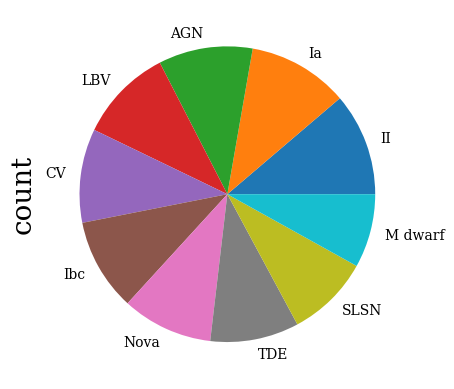

In [15]:
data['Class'].value_counts().plot.pie()
data['Class'].value_counts()

In [16]:
indx_type_to_consider = np.where(
	np.array([(data['Class'] == source) for source in sources_to_consider]).any(axis=0)
)

print(f"{len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}")
data = data.iloc[indx_type_to_consider[0]]

logtxt += f"Balanced: {len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}\n"
logtxt += "\n"

10 sources to consider: 282753


- Split features/target, handle missing values

In [17]:
X = data.drop(columns=['Sample_ID', 'Class', 'uid'])
y = data['Class']
X.fillna(-99, inplace=True)

In [18]:
y.unique()

array(['Ia', 'Ibc', 'II', 'SLSN', 'CV', 'LBV', 'AGN', 'M dwarf', 'Nova',
       'TDE'], dtype=object)

- Split into train/test using GroupShuffleSplit by uid

In [19]:
gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
train_idx, test_idx = next(gss.split(X, y, groups=data['uid']))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

- Label encode class for ML

In [20]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
class_names = np.array([str(c) for c in label_encoder.inverse_transform(np.arange(len(label_encoder.classes_)))])
print("Balanced: Class mapping:", class_names)

Balanced: Class mapping: ['AGN' 'CV' 'II' 'Ia' 'Ibc' 'LBV' 'M dwarf' 'Nova' 'SLSN' 'TDE']


In [21]:
# class_names = np.array([str(c) for c in label_encoder.inverse_transform(np.arange(len(label_encoder.classes_)))])
# class_names
# for key in data.keys():
#     print(f"""'{key}': float,""")

# Tests

In [22]:
xxx = """# LightGBM
# lgbm_exp = LightGBMExperiment(X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, params_lightgbm, eval_metrics_list, path_save)
# model, metrics = lgbm_exp.run()
# lgbm_exp.plot_confusion_matrix()
# lgbm_exp.plot_feature_importance()

# CatBoost
# cat_exp = CatBoostExperiment(X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, params_catboost, eval_metrics_list, path_save)
# model, metrics = cat_exp.run()

# XGBoost
# xgb_exp = XGBExperiment(X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, params_xgb, eval_metrics_list, path_save)
# model, metrics = xgb_exp.run()

# Random Forest
# rf_exp = RFExperiment(X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, params_rf, eval_metrics_list, path_save)
# model, metrics = rf_exp.run()

# MLP
# mlp_exp = MLPExperiment(X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, params_mlp, eval_metrics_list, path_save)
# model, metrics = mlp_exp.run()

# Autoencoder (custom code required)
# ae_exp = AutoencoderExperiment(X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, params_autoencoder, eval_metrics_list, path_save)
# model, metrics = ae_exp.run()

# TabNet
# tabnet_exp = TabNetExperiment(X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, params_tabnet, eval_metrics_list, path_save)
# model, metrics = tabnet_exp.run()

# EBM
# ebm_exp = EBMExperiment(X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, params_ebm, eval_metrics_list, path_save)
# model, metrics = ebm_exp.run()"""

In [23]:
classifier_type = 'normal_class_classifier'
model_param_config = model_config[classifier_type][device_type]

In [120]:
metrics_list = []
cm_dict = {}
eval_metrics_list = ["f1_macro", "f1_weighted", "precision_macro", "recall_macro", "accuracy"]

## LightGBM

[LightGBM] [Info] Total Bins 198900
[LightGBM] [Info] Number of data points in the train set: 227957, number of used features: 780
[LightGBM] [Info] Start training from score -2.306704
[LightGBM] [Info] Start training from score -2.313245
[LightGBM] [Info] Start training from score -2.203822
[LightGBM] [Info] Start training from score -2.202908
[LightGBM] [Info] Start training from score -2.308026
[LightGBM] [Info] Start training from score -2.296231
[LightGBM] [Info] Start training from score -2.336253
[LightGBM] [Info] Start training from score -2.333444
[LightGBM] [Info] Start training from score -2.416469
[LightGBM] [Info] Start training from score -2.326590
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[54]	train's multi_logloss: 0.179429	test's multi_logloss: 0.814709


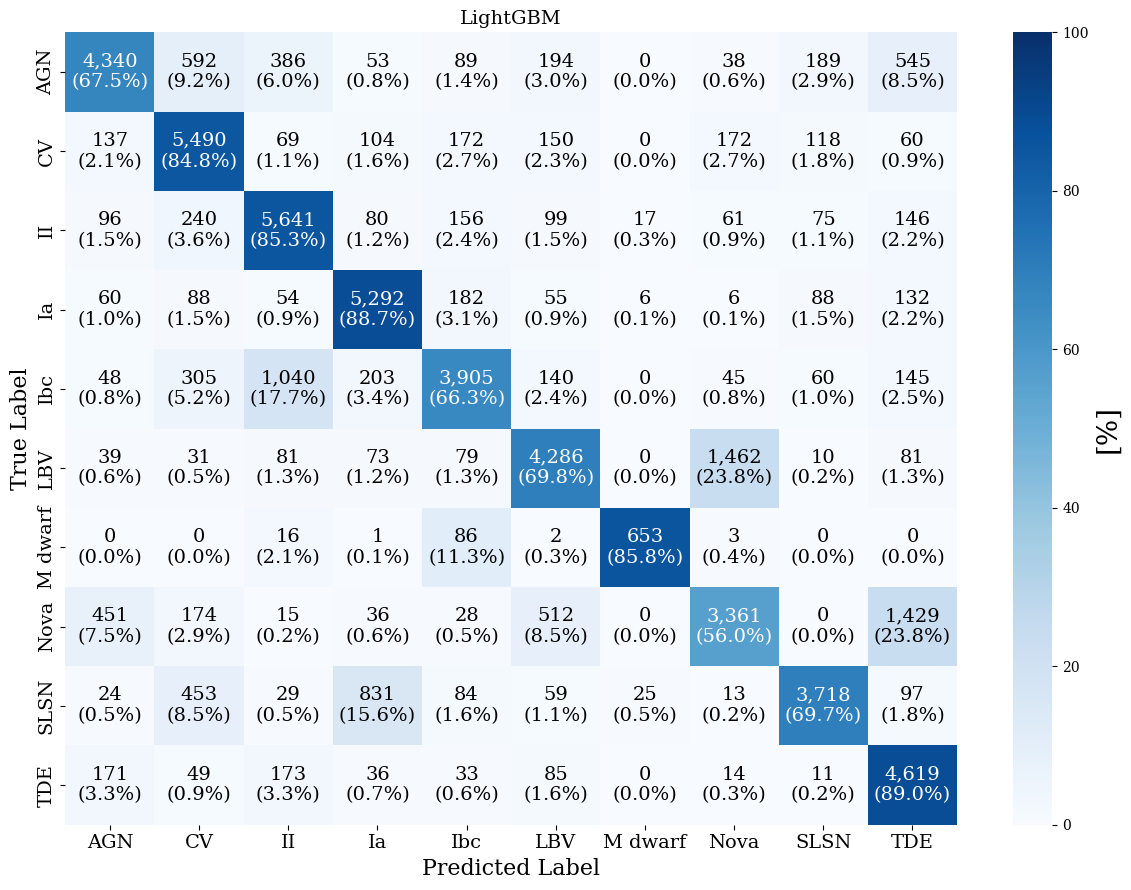

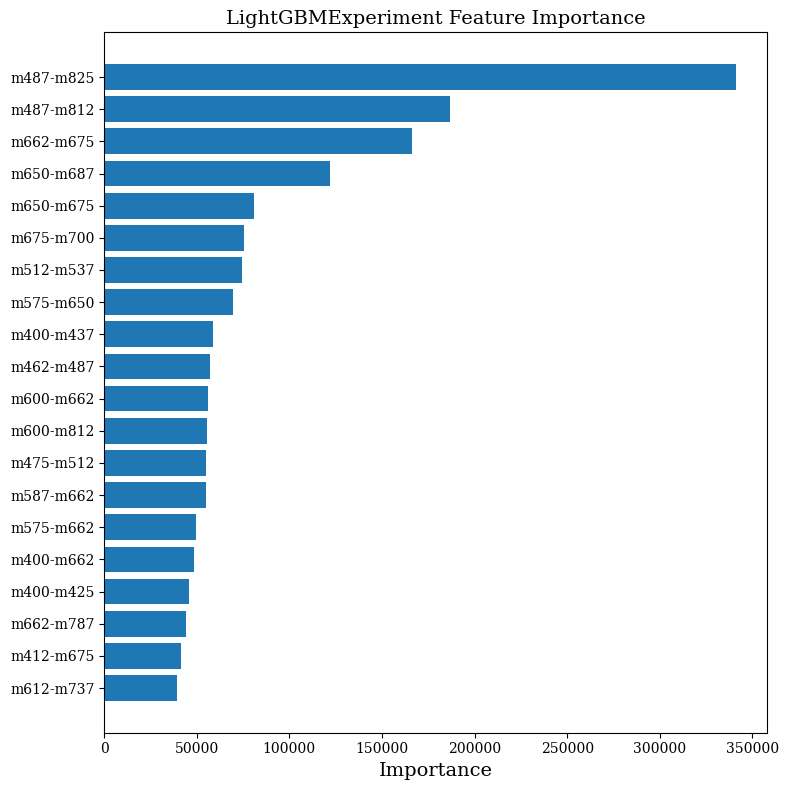

In [25]:
params_lightgbm = model_param_config['params_lightgbm']
params_lightgbm['num_class'] = len(label_encoder.classes_)

# LightGBM
lgbm_exp = LightGBMExperiment(X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, params_lightgbm, eval_metrics_list, path_save)
model, metrics = lgbm_exp.run()
lgbm_exp.plot_confusion_matrix()
lgbm_exp.plot_feature_importance()

In [121]:
cm, labels = lgbm_exp.get_confusion_matrix()
metrics_list.append(lgbm_exp.metrics_df)
cm_dict['LightGBM'] = cm

## CatBoost

In [37]:
params_catboost = model_param_config['params_catboost']
params_catboost.pop('num_class', None)
params_catboost.pop('random_seed', None)

# CatBoost
cat_exp = CatBoostExperiment(X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, params_catboost, eval_metrics_list, path_save)
model, metrics = cat_exp.run()

TBB Warning: The number of workers is currently limited to 39. The request for 47 workers is ignored. Further requests for more workers will be silently ignored until the limit changes.



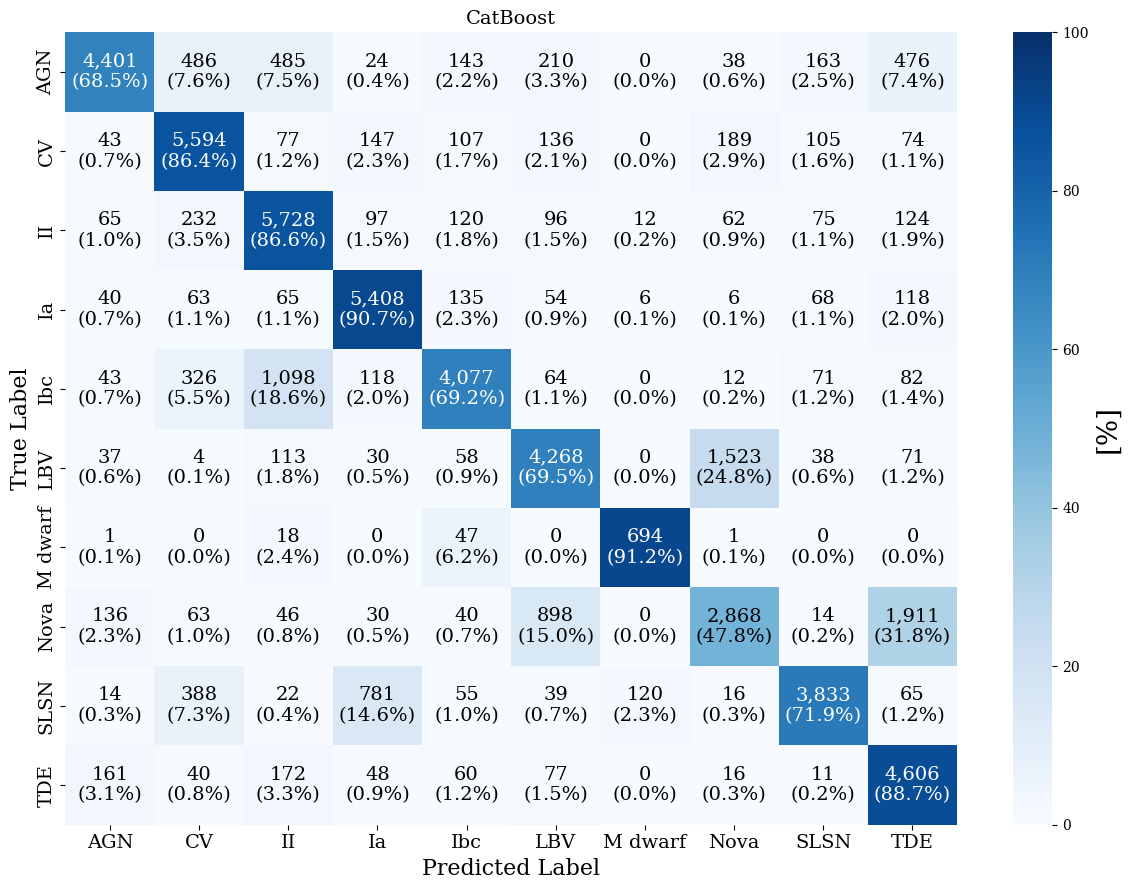

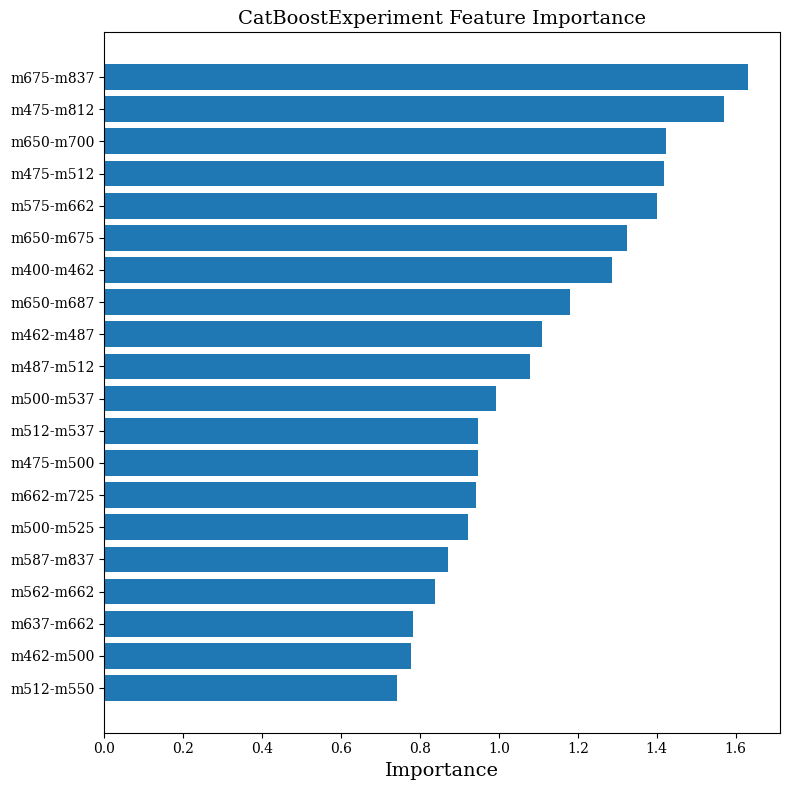

In [72]:
cat_exp.plot_confusion_matrix()
cat_exp.plot_feature_importance()

In [122]:
cm, labels = cat_exp.get_confusion_matrix()
metrics_list.append(cat_exp.metrics_df)
cm_dict['CatBoost'] = cm

## XGBoost

In [41]:
params_xgb = model_param_config['params_xgb']
params_xgb['num_class'] = len(label_encoder.classes_)
# params_xgb.pop('random_seed', None)
params_xgb.pop('random_state', None)

# XGBoost
xgb_exp = XGBExperiment(X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, params_xgb, eval_metrics_list, path_save)
model, metrics = xgb_exp.run()

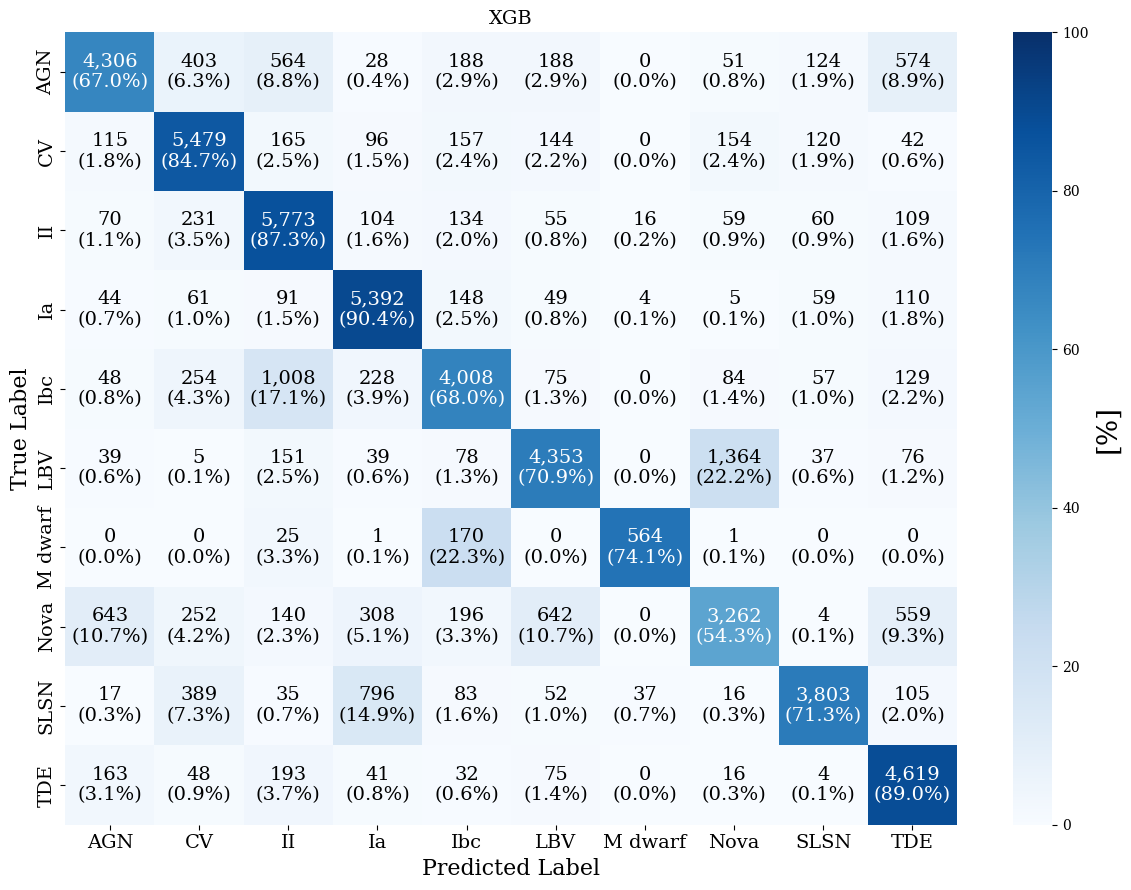

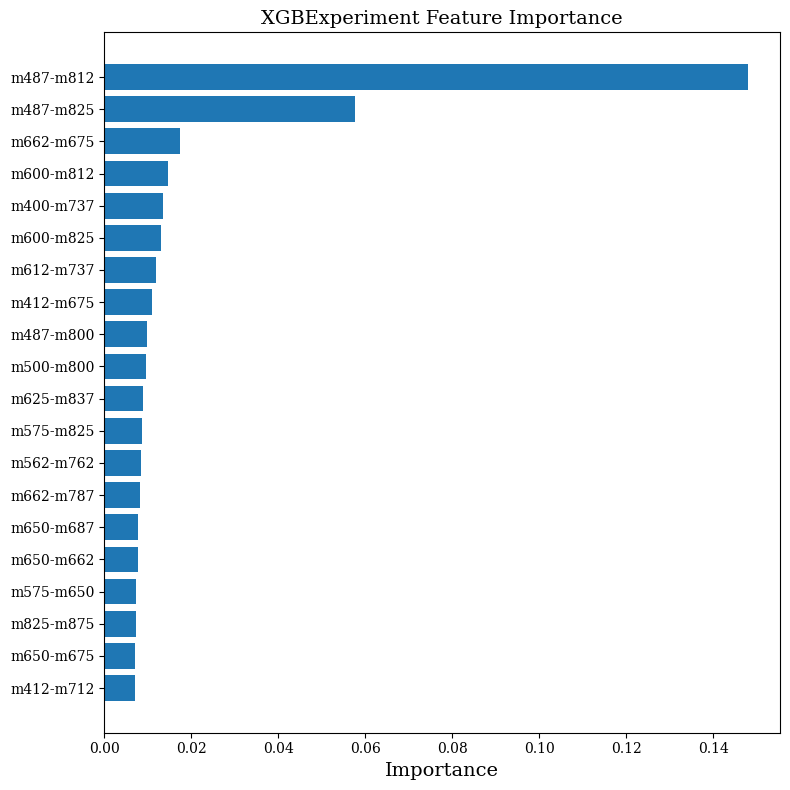

In [73]:
xgb_exp.plot_confusion_matrix()
xgb_exp.plot_feature_importance()

In [123]:
cm, labels = xgb_exp.get_confusion_matrix()
metrics_list.append(xgb_exp.metrics_df)
cm_dict['XGBoost'] = cm

## Random Forest

In [45]:
params_rf = model_param_config['params_rf']
# params_rf['num_class'] = len(label_encoder.classes_)
params_rf.pop('random_state', None)
params_rf.pop('num_class', None)

# Random Forest
rf_exp = RFExperiment(X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, params_rf, eval_metrics_list, path_save)
model, metrics = rf_exp.run()

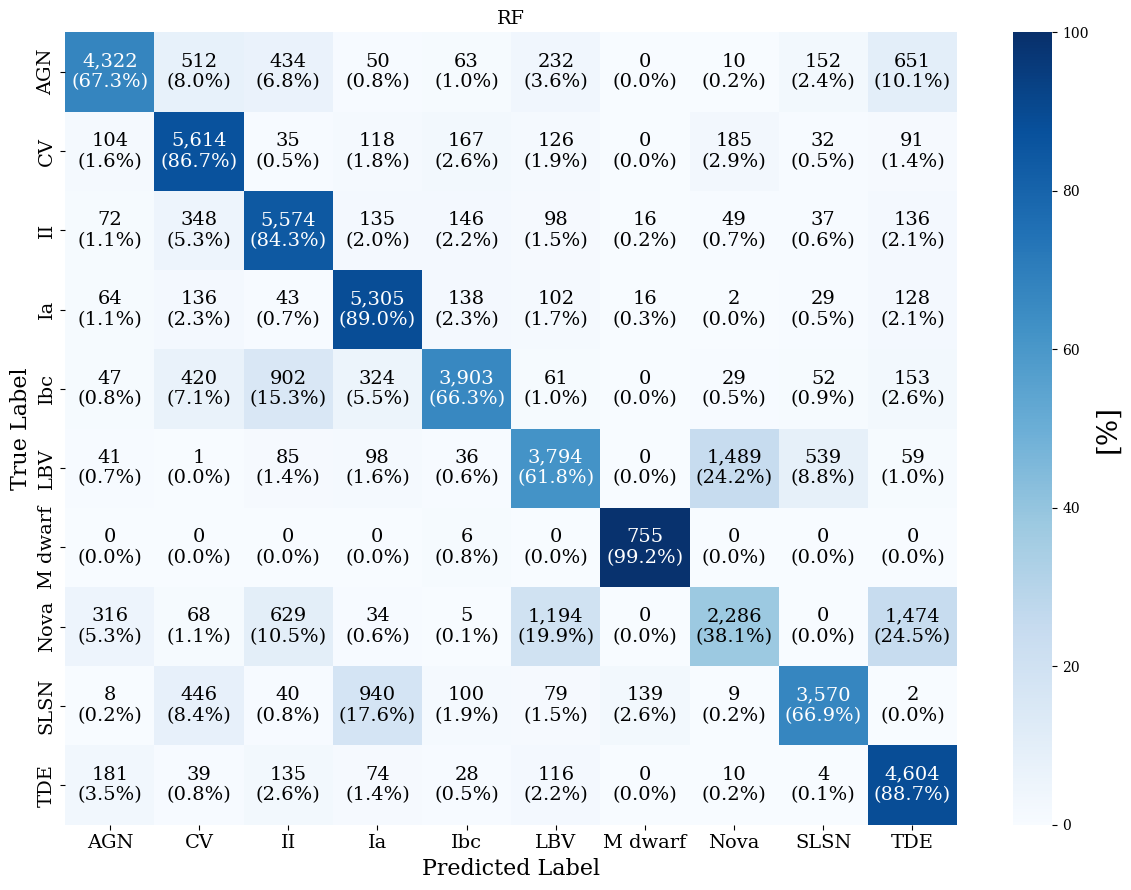

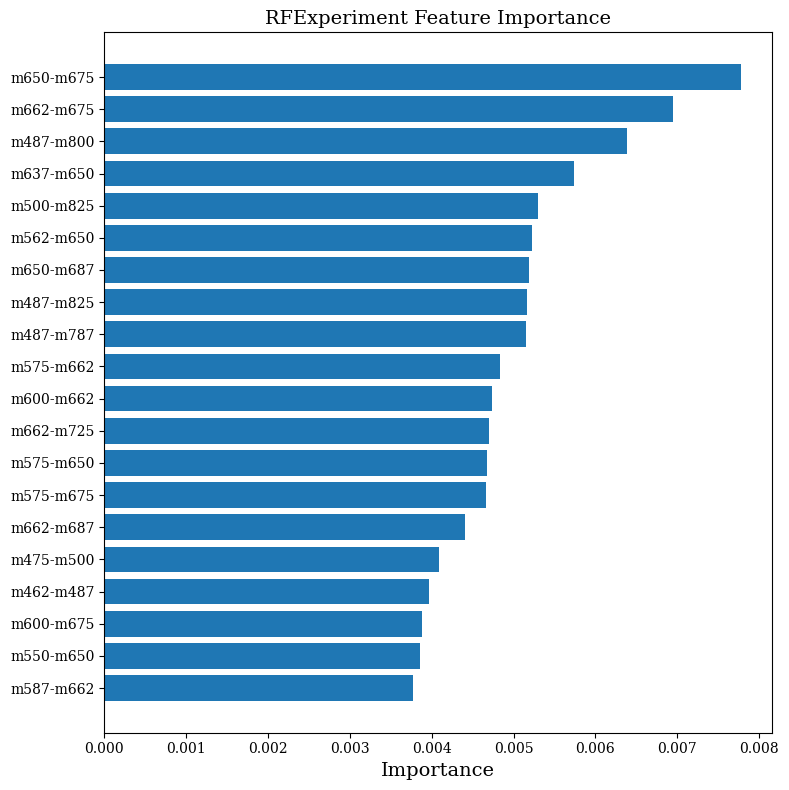

In [84]:
rf_exp.plot_confusion_matrix()
rf_exp.plot_feature_importance()

In [124]:
cm, labels = rf_exp.get_confusion_matrix()
metrics_list.append(rf_exp.metrics_df)
cm_dict['RandomForest'] = cm

## MLP

In [52]:
params_mlp = model_param_config['params_mlp']
params_mlp['num_class'] = len(label_encoder.classes_)
params_mlp.pop('random_state', None)
params_mlp.pop('num_class', None)

# MLP
mlp_exp = MLPExperiment(X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, params_mlp, eval_metrics_list, path_save)
model, metrics = mlp_exp.run()

Feature importance not supported for MLPExperiment


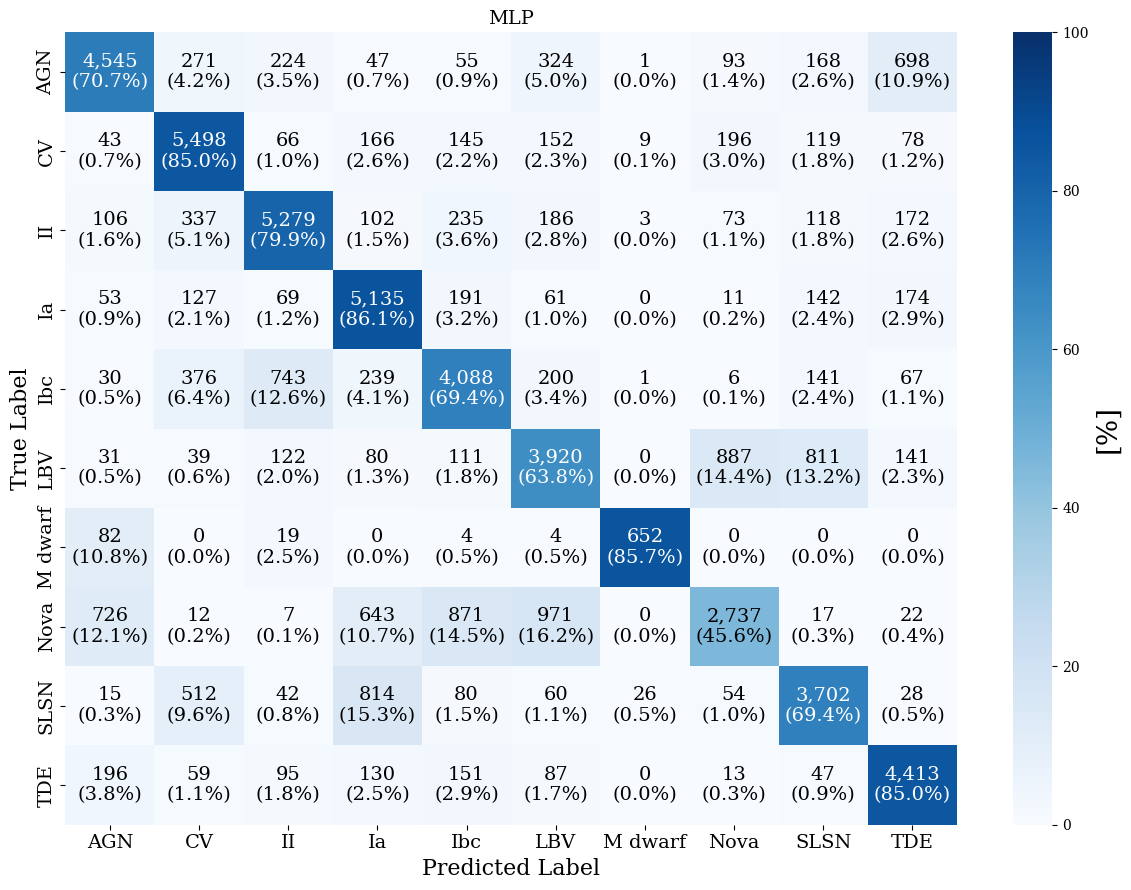

In [75]:
mlp_exp.plot_confusion_matrix()
mlp_exp.plot_feature_importance()

In [125]:
cm, labels = mlp_exp.get_confusion_matrix()
metrics_list.append(mlp_exp.metrics_df)
cm_dict['MLP'] = cm

## Autoencoder (no use)

In [54]:
class AutoencoderExperiment(BaseExperiment):
    """
    Autoencoder placeholder class (actual implementation depends on deep learning backend).
    """
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # You would initialize your AE here

    def run(self):
        """
        Runs autoencoder-based training and classification.
        """
        print("Autoencoder: Placeholder for run logic (implement with keras/torch).")
        self.y_pred = np.zeros_like(self.y_test)  # Dummy prediction
        self._metrics_post()
        return self.model, self.metrics_df

    def plot_feature_importance(self, max_num=20):
        """
        Prints a warning (feature importance not supported for Autoencoder).
        """
        print(f"Feature importance not supported for {self.__class__.__name__}")

In [61]:
# params_autoencoder = model_param_config['params_autoencoder']
# params_autoencoder['num_class'] = len(label_encoder.classes_)

# # Autoencoder (custom code required)
# ae_exp = AutoencoderExperiment(X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, params_autoencoder, eval_metrics_list, path_save)
# model, metrics = ae_exp.run()


## TabNet

In [67]:
params_tabnet = model_param_config['params_tabnet']
params_tabnet['num_class'] = len(label_encoder.classes_)
params_tabnet.pop('num_class', None)

# TabNet
tabnet_exp = TabNetExperiment(X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, params_tabnet, eval_metrics_list, path_save)
model, metrics = tabnet_exp.run()


epoch 0  | loss: 1.76965 | val_0_accuracy: 0.3899  |  0:00:29s
epoch 1  | loss: 1.21262 | val_0_accuracy: 0.45076 |  0:01:01s
epoch 2  | loss: 1.0561  | val_0_accuracy: 0.39941 |  0:01:33s
epoch 3  | loss: 0.97038 | val_0_accuracy: 0.45321 |  0:02:03s
epoch 4  | loss: 0.87577 | val_0_accuracy: 0.45551 |  0:02:32s
epoch 5  | loss: 0.80696 | val_0_accuracy: 0.48785 |  0:03:00s
epoch 6  | loss: 0.78125 | val_0_accuracy: 0.53172 |  0:03:26s
epoch 7  | loss: 0.75795 | val_0_accuracy: 0.54659 |  0:03:53s
epoch 8  | loss: 0.71995 | val_0_accuracy: 0.5259  |  0:04:21s
epoch 9  | loss: 0.70396 | val_0_accuracy: 0.53621 |  0:04:47s
epoch 10 | loss: 0.68168 | val_0_accuracy: 0.52307 |  0:05:12s
epoch 11 | loss: 0.66551 | val_0_accuracy: 0.52633 |  0:05:40s
epoch 12 | loss: 0.64803 | val_0_accuracy: 0.56875 |  0:06:02s
epoch 13 | loss: 0.62979 | val_0_accuracy: 0.52037 |  0:06:25s
epoch 14 | loss: 0.63823 | val_0_accuracy: 0.52714 |  0:06:47s
epoch 15 | loss: 0.62922 | val_0_accuracy: 0.56519 |  0

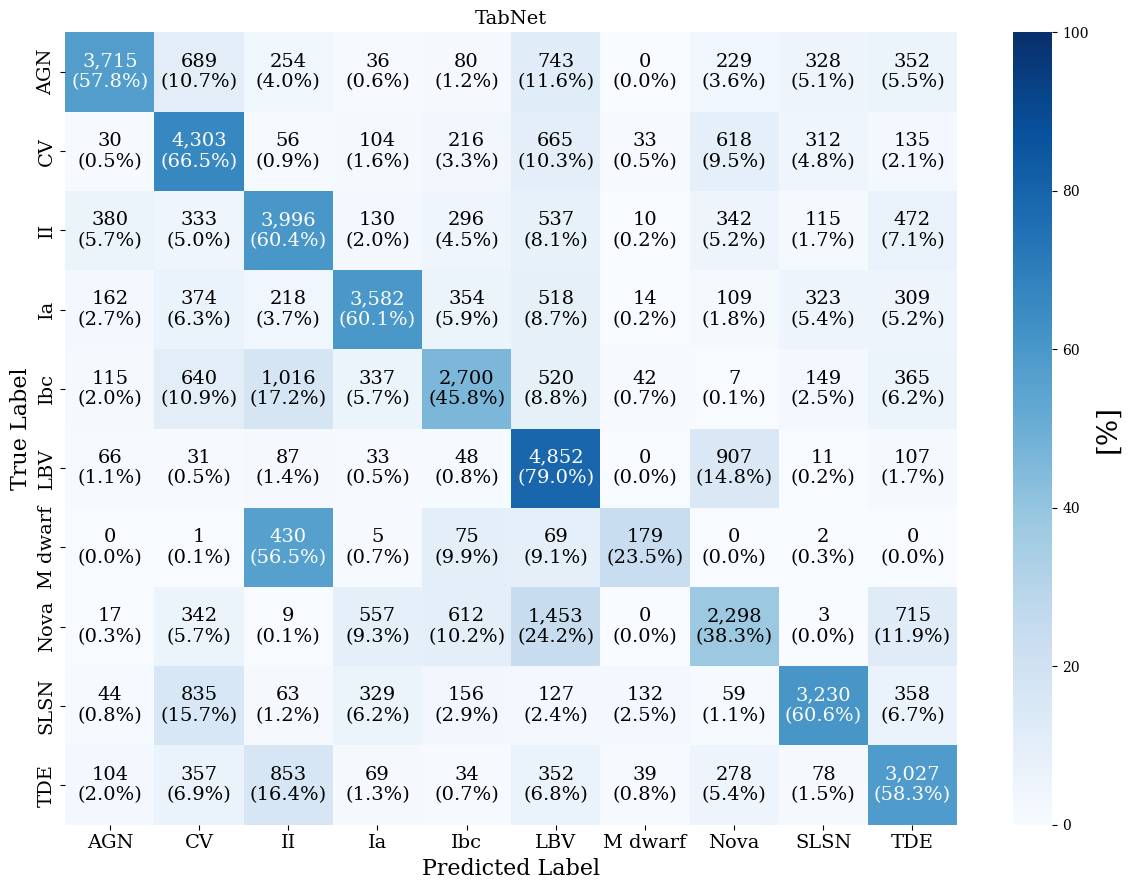

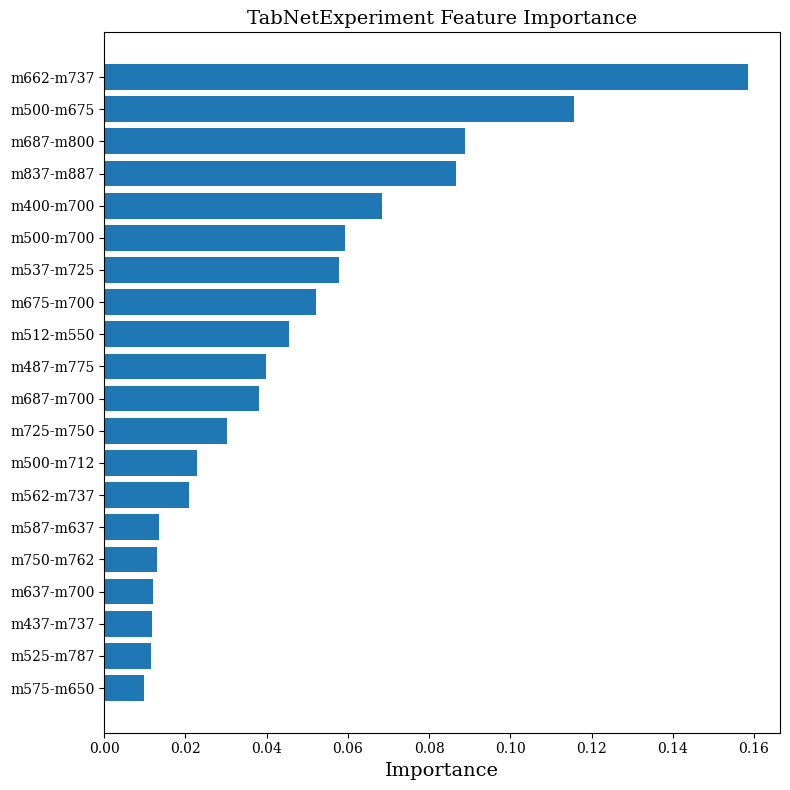

In [76]:
tabnet_exp.plot_confusion_matrix()
tabnet_exp.plot_feature_importance()

In [126]:
cm, labels = tabnet_exp.get_confusion_matrix()
metrics_list.append(tabnet_exp.metrics_df)
cm_dict['TabNet'] = cm

## EBM

In [70]:
params_ebm = model_param_config['params_ebm']
# params_ebm['params_ebm'] = len(label_encoder.classes_)

# EBM
ebm_exp = EBMExperiment(X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, params_ebm, eval_metrics_list, path_save)
model, metrics = ebm_exp.run()

Feature importance not supported for EBMExperiment: 'ExplainableBoostingClassifier' object has no attribute 'feature_importances_'


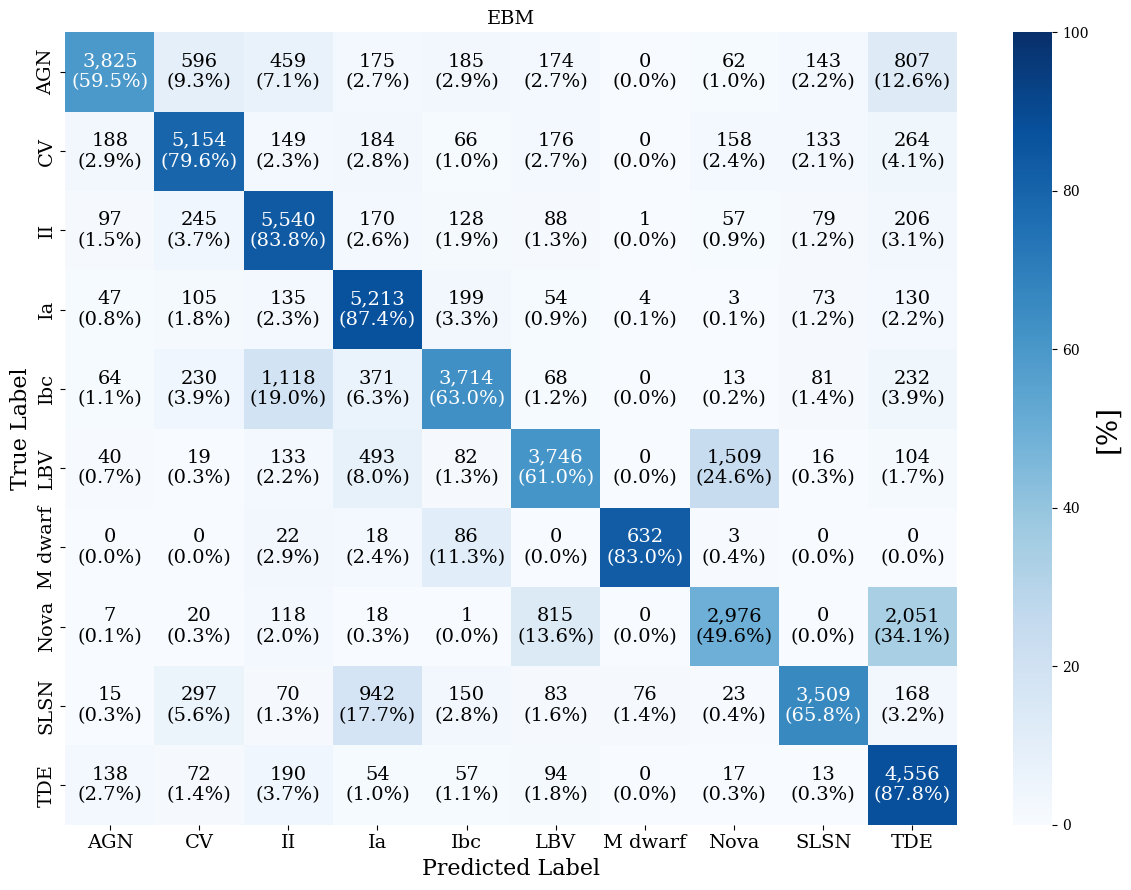

In [77]:
ebm_exp.plot_confusion_matrix()
ebm_exp.plot_feature_importance()

In [127]:
cm, labels = ebm_exp.get_confusion_matrix()
metrics_list.append(ebm_exp.metrics_df)
cm_dict['EBM'] = cm

# Result

In [129]:
metrics_df = pd.concat(metrics_list, ignore_index=True)
metrics_df['model'] = ['LightGBM', 'CatBoost', 'XGBoost', 'Random Forest', 'MLP', 'TabNet', 'EBM']
metrics_df

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,LightGBM,0.753796,0.775669,0.762976,0.763282,0.751365
1,CatBoost,0.756935,0.770978,0.770505,0.763310,0.753929
2,XGBoost,0.758431,0.776061,0.757040,0.760918,0.754948
3,Random Forest,0.724998,0.735626,0.748212,0.732681,0.717814
4,MLP,0.729415,0.745635,0.740539,0.739263,0.724687
5,TabNet,0.581831,0.579456,0.550305,0.554643,0.580066
6,EBM,0.709267,0.741919,0.720581,0.719242,0.707179


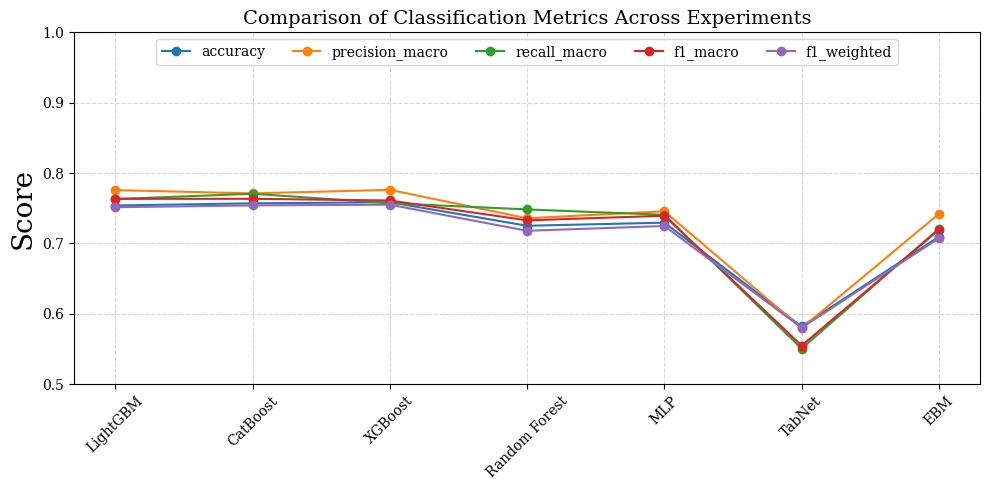

In [133]:
# Plot metrics comparison
metrics_to_plot = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_weighted"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

plt.figure(figsize=(10, 5))

for i, metric in enumerate(metrics_to_plot):
    plt.plot(metrics_df["model"], metrics_df[metric], marker='o', label=metric, color=colors[i])

plt.xticks(rotation=45)
plt.ylabel("Score")
plt.ylim(0.5, 1.0)
plt.title("Comparison of Classification Metrics Across Experiments")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper center', ncol=10)
plt.tight_layout()
plt.show()

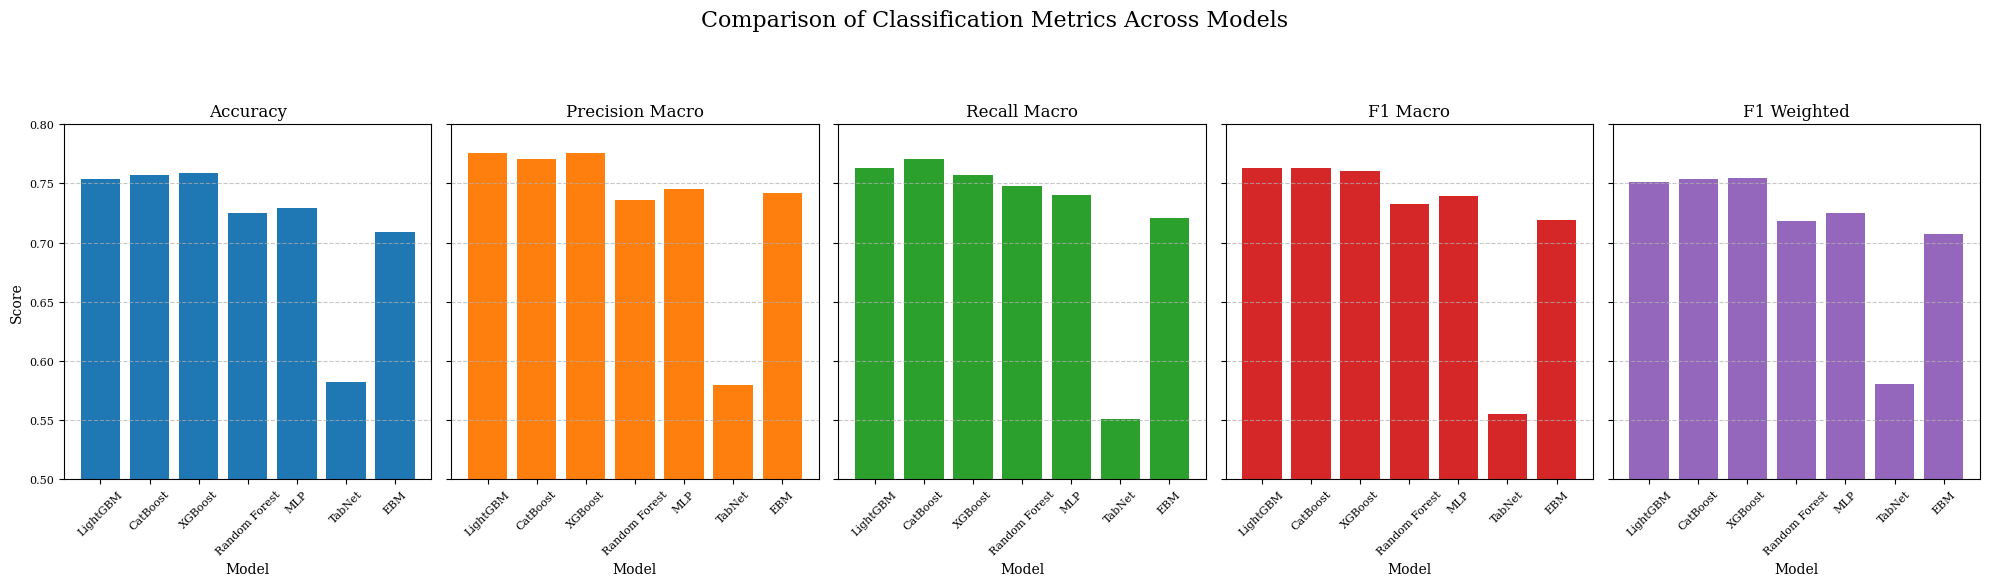

In [137]:
# Define the metrics to plot and custom colors as per your image
metrics_to_plot = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_weighted"]
# Using a list of distinct colors for each metric, as suggested by your line plot code
# You can customize these hex codes or use Matplotlib's named colors
metric_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

# Set up the figure and axes
# We will create a separate subplot for each metric
fig, axes = plt.subplots(nrows=1, ncols=len(metrics_to_plot), figsize=(20, 6), sharey=True)
# Adjust figsize as needed to fit all plots comfortably

# Loop through each metric to create a bar graph
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i] # Get the current subplot axis

    # Plot bars for the current metric for all models
    ax.bar(metrics_df['model'], metrics_df[metric], color=metric_colors[i])

    # Set titles and labels for each subplot
    ax.set_title(f'{metric.replace("_", " ").title()}', fontsize=12) # Title for each metric
    ax.set_xlabel('Model', fontsize=10) # X-axis label for models
    if i == 0: # Only set y-label for the first plot to avoid redundancy due to sharey=True
        ax.set_ylabel('Score', fontsize=10)
    
    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    # Set y-axis limits
    ax.set_ylim(0.5, 0.8) # From the line plot, scores range from 0.5 to 1.05, adjusting to 0.5 to 1.0 here for bar visibility

    # Add grid
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Set a super title for the entire figure
plt.suptitle('Comparison of Classification Metrics Across Models', fontsize=16, y=1.02)

plt.tight_layout(rect=[0, 0.05, 1, 0.95]) # Adjust layout to prevent labels from overlapping and make space for suptitle
plt.show()

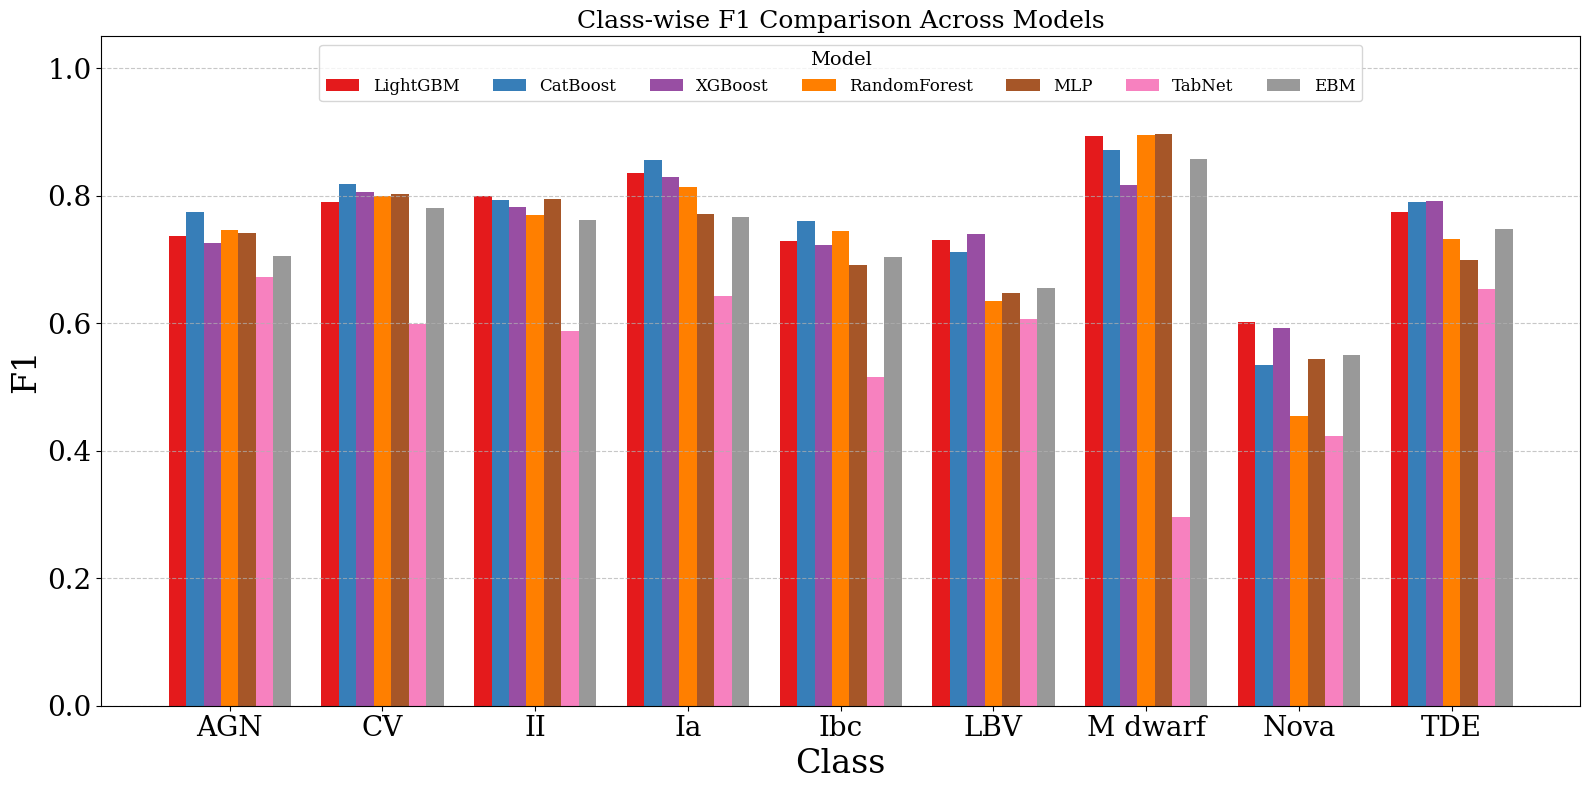

In [107]:
# List to store metrics for each class
records = []

for name, cm in cm_dict.items():
    y_true = []
    y_pred = []
    # Reconstruct y_true and y_pred from the confusion matrix
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            y_true.extend([i] * cm[i, j])
            y_pred.extend([j] * cm[i, j])
    # Calculate precision, recall, and f1-score for each class
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(class_names)), zero_division=0
    )
    # Append the calculated metrics to records
    for i, cls in enumerate(class_names):
        records.append({
            'experiment': name,
            'class': cls,
            'precision': precision[i],
            'recall': recall[i],
            'f1': f1[i]
        })

# Convert the list of dictionaries to a DataFrame
df_metrics = pd.DataFrame(records)

# --- Visualization ---
# metrics = ['precision', 'recall', 'f1']
metrics = ['f1']

# Get the unique experiment names (models)
models = list(cm_dict.keys())
num_models = len(models)
bar_width = 0.8 / num_models # Adjust bar width dynamically based on the number of models

# Define a set of colors for different models for better distinction
colors = plt.cm.get_cmap('Set1', num_models)

for metric in metrics:
    plt.figure(figsize=(16, 8)) # Increase figure size for better readability with more bars
    
    # Calculate the positions for each set of bars
    x = np.arange(len(class_names)) # Positions for the class labels
    
    for i, model_name in enumerate(models):
        subset = df_metrics[df_metrics['experiment'] == model_name]
        # Calculate the offset for each model's bars to group them by class
        # The total width used by all bars for one class is num_models * bar_width
        # We want to center this group around the x-tick.
        offset = x - (num_models - 1) * bar_width / 2 + i * bar_width
        plt.bar(offset, subset[metric], bar_width, label=model_name, color=colors(i))
    
    plt.title(f'Class-wise {metric.title()} Comparison Across Models', fontsize=18)
    plt.ylabel(metric.title(), fontsize=24)
    plt.xlabel('Class', fontsize=24)
    plt.ylim(0, 1.05) # Set y-axis limits
    plt.xticks(x, class_names, rotation=0, ha='center', fontsize=20) # Set x-ticks to class names
    plt.yticks(fontsize=20)
    plt.legend(title='Model', fontsize=12, title_fontsize=14, loc='upper center', ncol=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7) # Add horizontal grid lines
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

In [ ]:
# 모든 결과를 하나의 csv로 저장
metrics_all = pd.concat(metrics_list, ignore_index=True)
metrics_all.to_csv(os.path.join(path_save, "metrics_summary.csv"), index=False)
print("Experiment complete. Results saved in:", path_save)

Experiment complete. Results saved in: /Users/paek/Research/7DT/SED-Classifier/notebook/../model/different_sampling
